Seaborn Study Introduction

Using Palmer Penguins Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("processed_penguins.csv")
df = df.loc[:, ["species", "island", "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "sex", "year"]]
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [3]:
df["species"].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

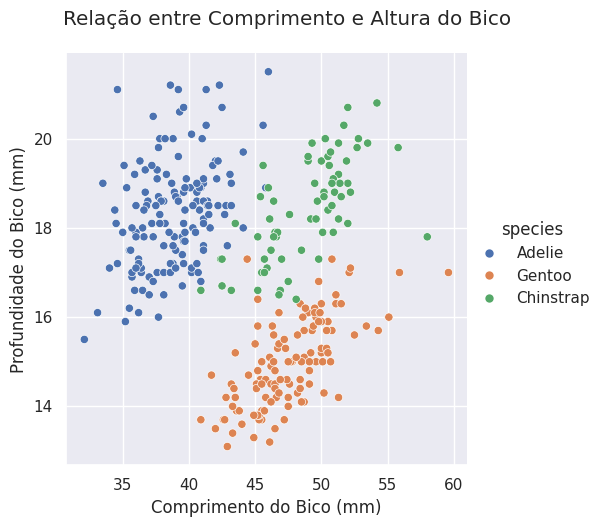

In [4]:
sns.set_theme()

g_length_and_depth_rel = sns.relplot(data=df,
                       x="bill_length_mm", y="bill_depth_mm", hue="species")
g_length_and_depth_rel.set_axis_labels("Comprimento do Bico (mm)", "Profundidade do Bico (mm)")
g_length_and_depth_rel.figure.suptitle("Relação entre Comprimento e Altura do Bico", y=1.05)
plt.show()


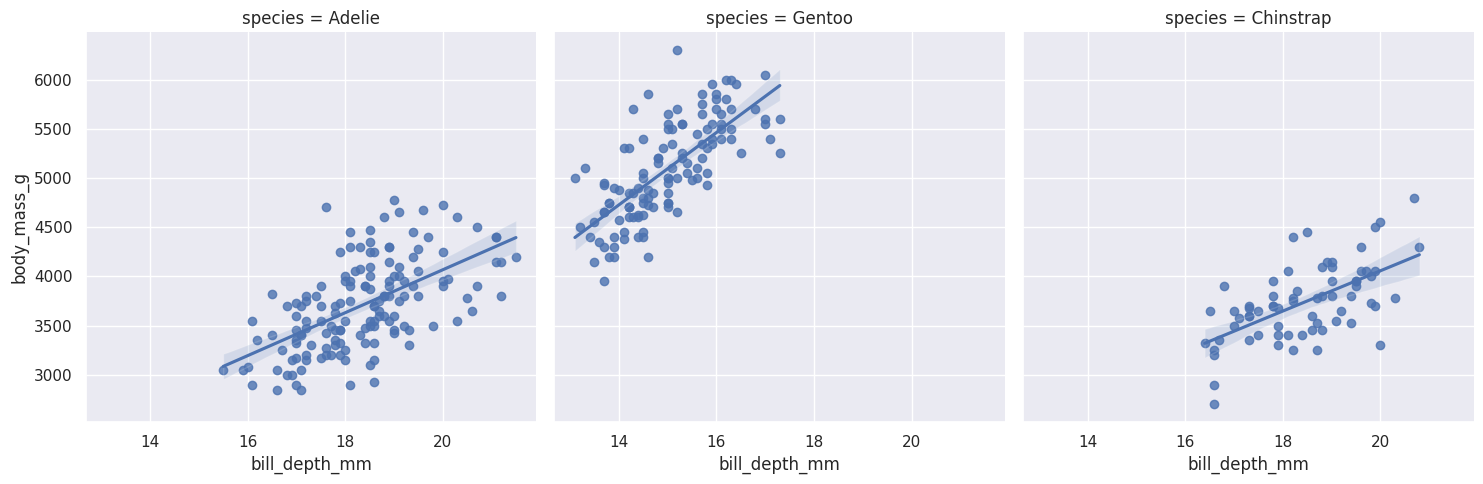

In [5]:
sns.lmplot(data=df,
           x="bill_depth_mm", y="body_mass_g", col="species")

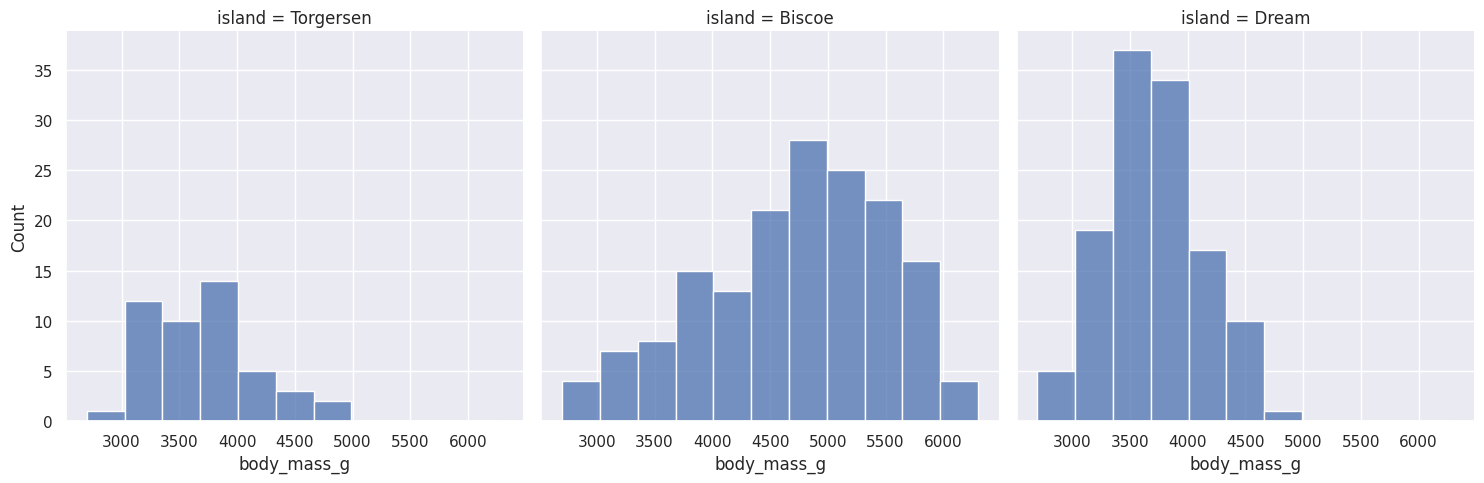

In [6]:
sns.displot(data=df, x="body_mass_g", col="island")

<Axes: >

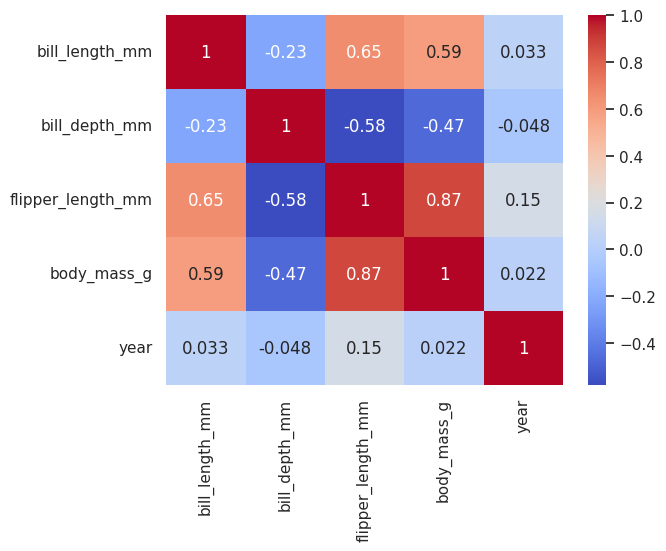

In [7]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")

<Axes: xlabel='species', ylabel='count'>

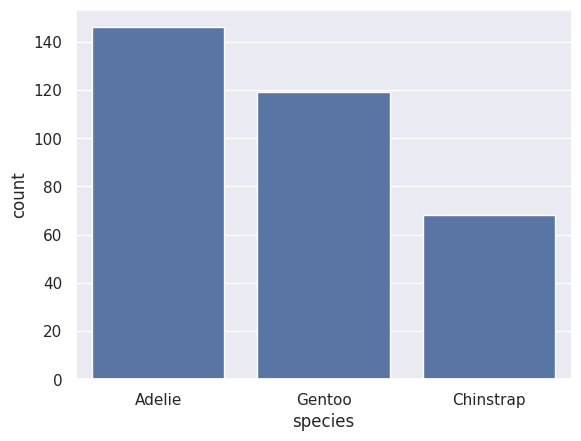

In [8]:
sns.countplot(data=df, x="species")

Exercicios 1

<Axes: xlabel='body_mass_g', ylabel='Density'>

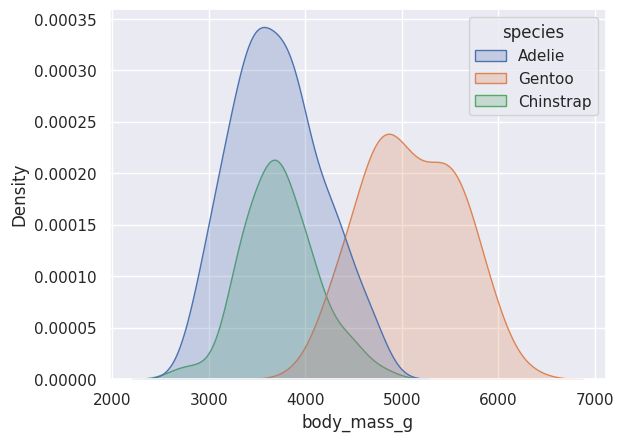

In [9]:
sns.kdeplot(data=df, x="body_mass_g", hue="species", fill=True)

A distribuição da massa corporal é simétrica?
- As espécies Adelie e Chinstrap apresentam distribuição de massa corporal quase simétricas, enquanto a espécie Gentoo já apresenta uma assimetria aproximadamente positiva.

Existe sobreposição entre espécies?
- Há sim sobreposição de espécies no gráfico. As espécies Adelie e Chinstrap evidenciam uma distribuição de massa corporal muito parecidas. O gŕafico também mostra que os pinguins da espécie Gentoo que apresentam menor massa corporal possuem pesos similares aos pinguins das espécies Adelie e Chinstrap que apresentam maior massa corporal.

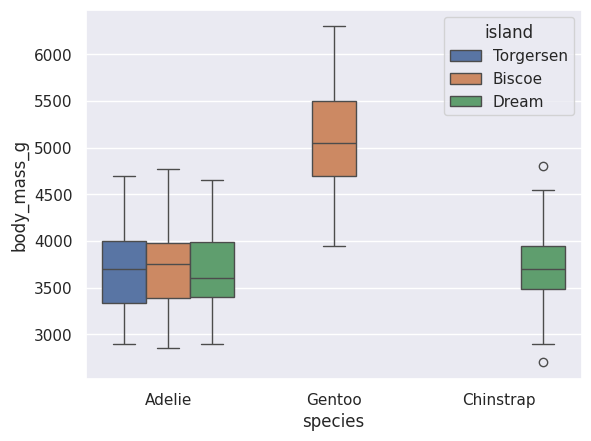

In [10]:
g = sns.boxplot(data=df,
            x="species", y="body_mass_g", hue="island")
plt.show()

A massa corporal varia mais por espécie ou por ilha?
- Nota-se que a ilha não influencia na massa corporal de cada espécie. Fica evidente pela espécie Adelie, que mesmo tendo presença nas três ilhas, mantém sua distribuição de massa corporal quase que similar.

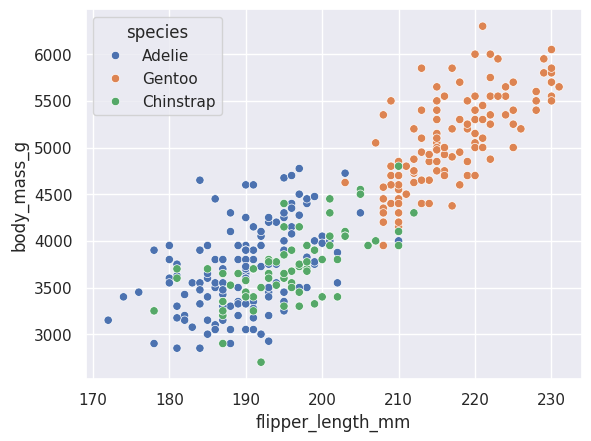

In [86]:
sns.scatterplot(data=df,
                x="flipper_length_mm", y="body_mass_g", hue="species")
plt.show()

<Axes: >

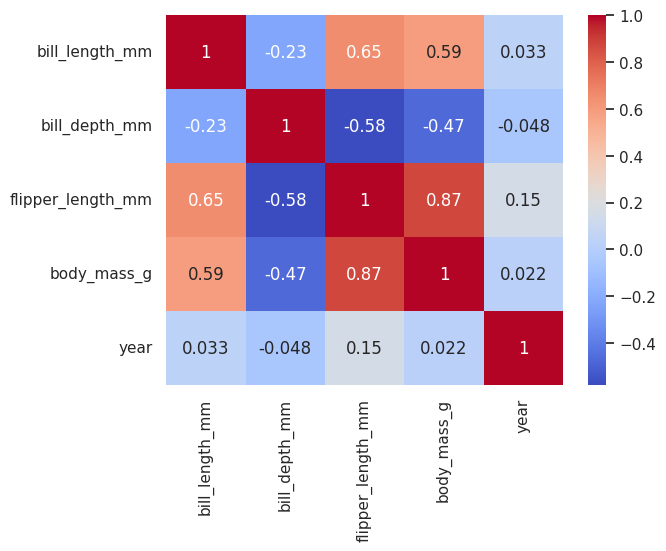

In [87]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")

Existe correlação linear forte?
- Existe uma correlação linear positiva e forte (0.87).

Exercicios 2

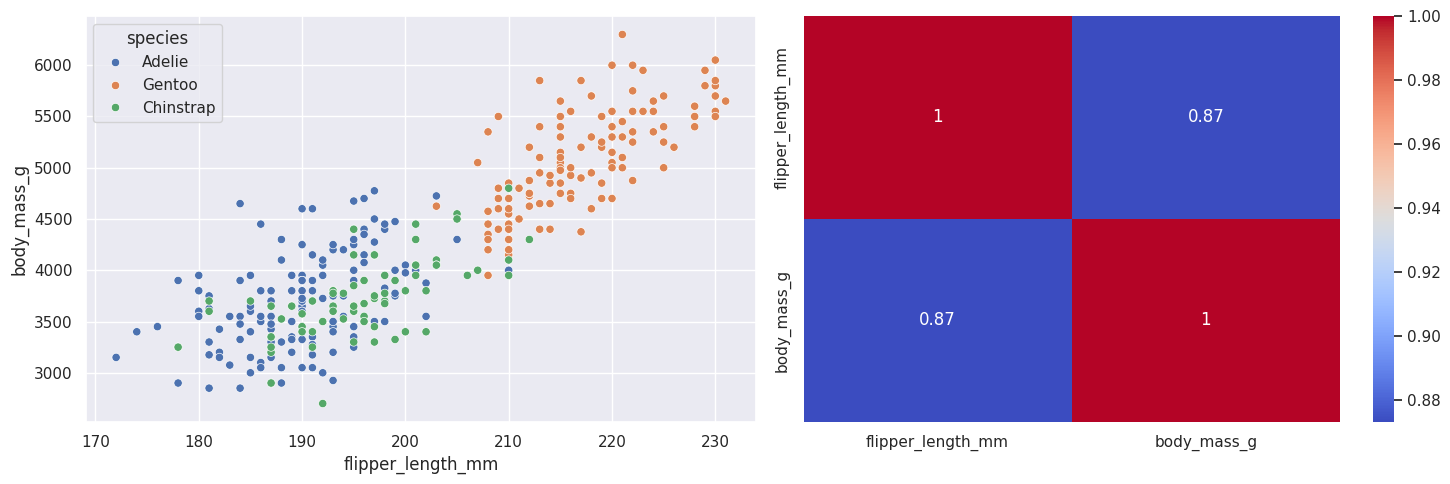

In [93]:
_, axes = plt.subplots(1, 2, figsize=(15,5))

sns.scatterplot(data=df,
                x="flipper_length_mm", y="body_mass_g", hue="species", ax=axes[0])

selected_df = df.loc[:, ["flipper_length_mm", "body_mass_g"]]
corr = selected_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1])

plt.tight_layout()
plt.show()

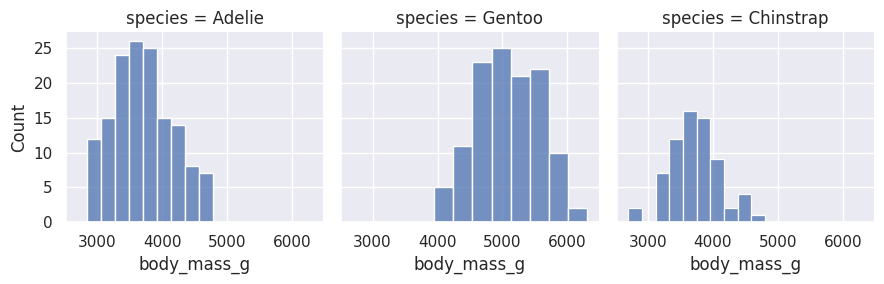

In [89]:
g = sns.FacetGrid(df, col="species")
g.map(sns.histplot, "body_mass_g")

/home/vinicius/Documentos/codes/ic_data_science/venv/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


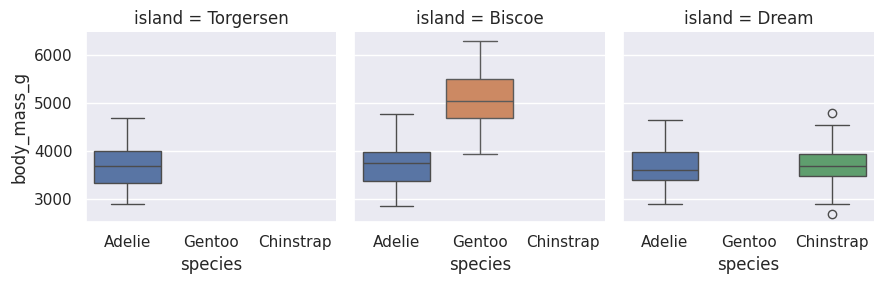

In [90]:
g = sns.FacetGrid(data=df, col="island", hue="species")
g.map(sns.boxplot, "species", "body_mass_g")

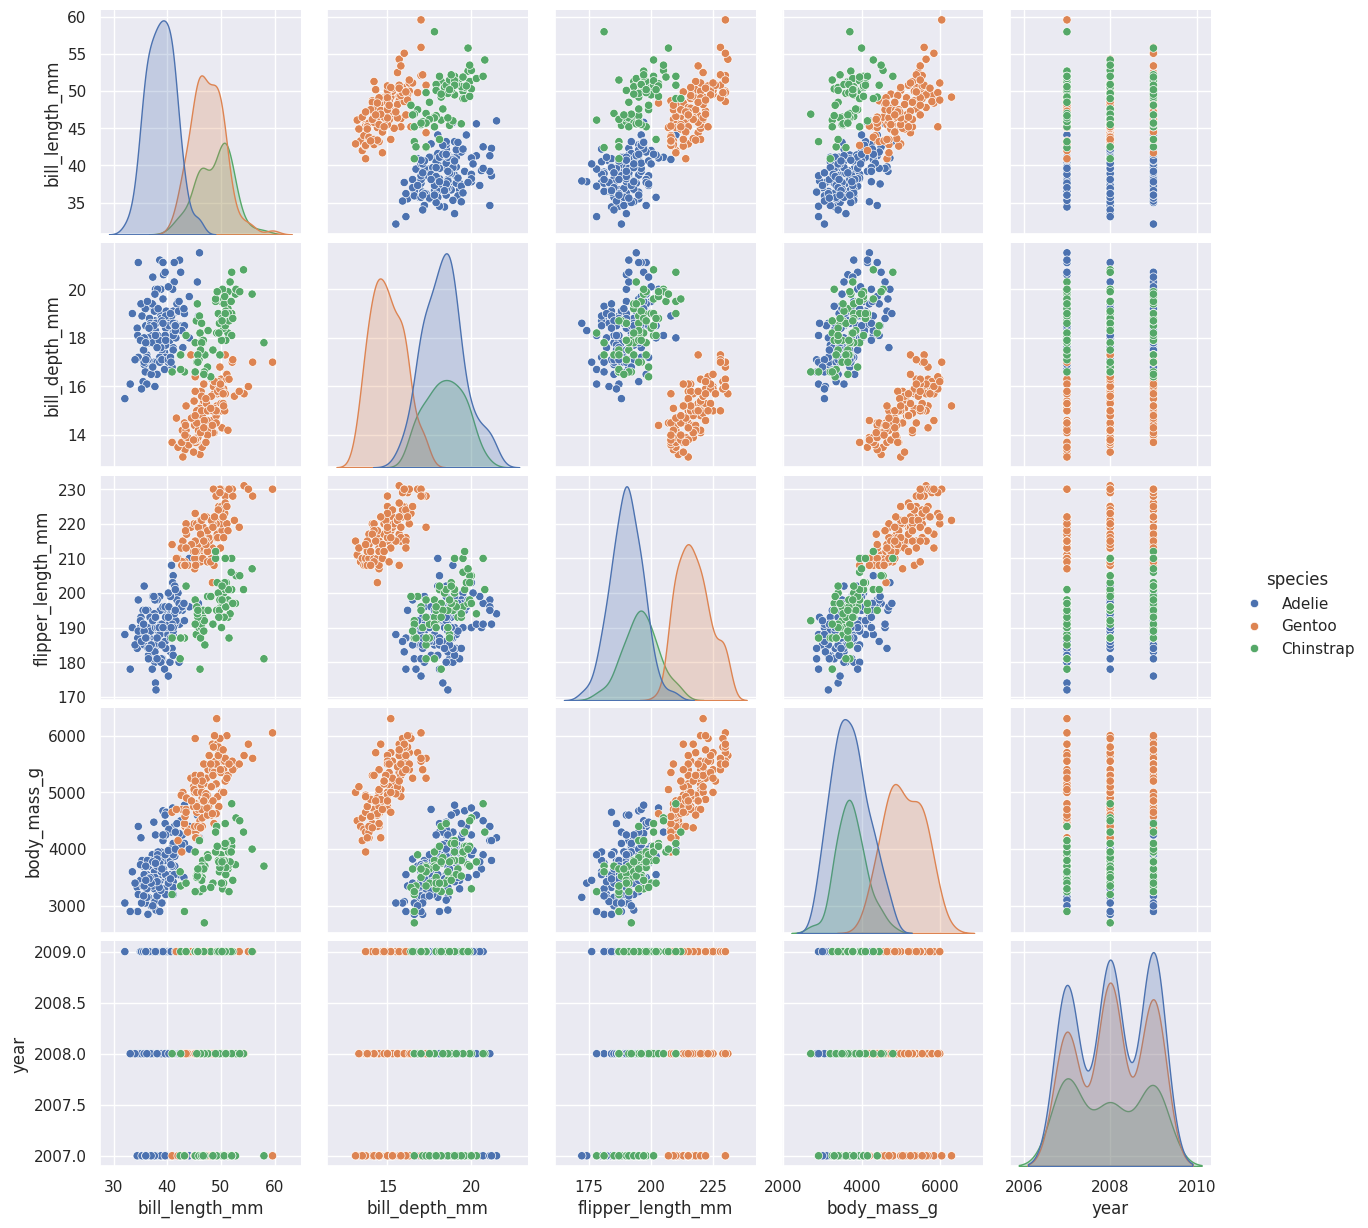

In [91]:
sns.pairplot(df, hue="species")

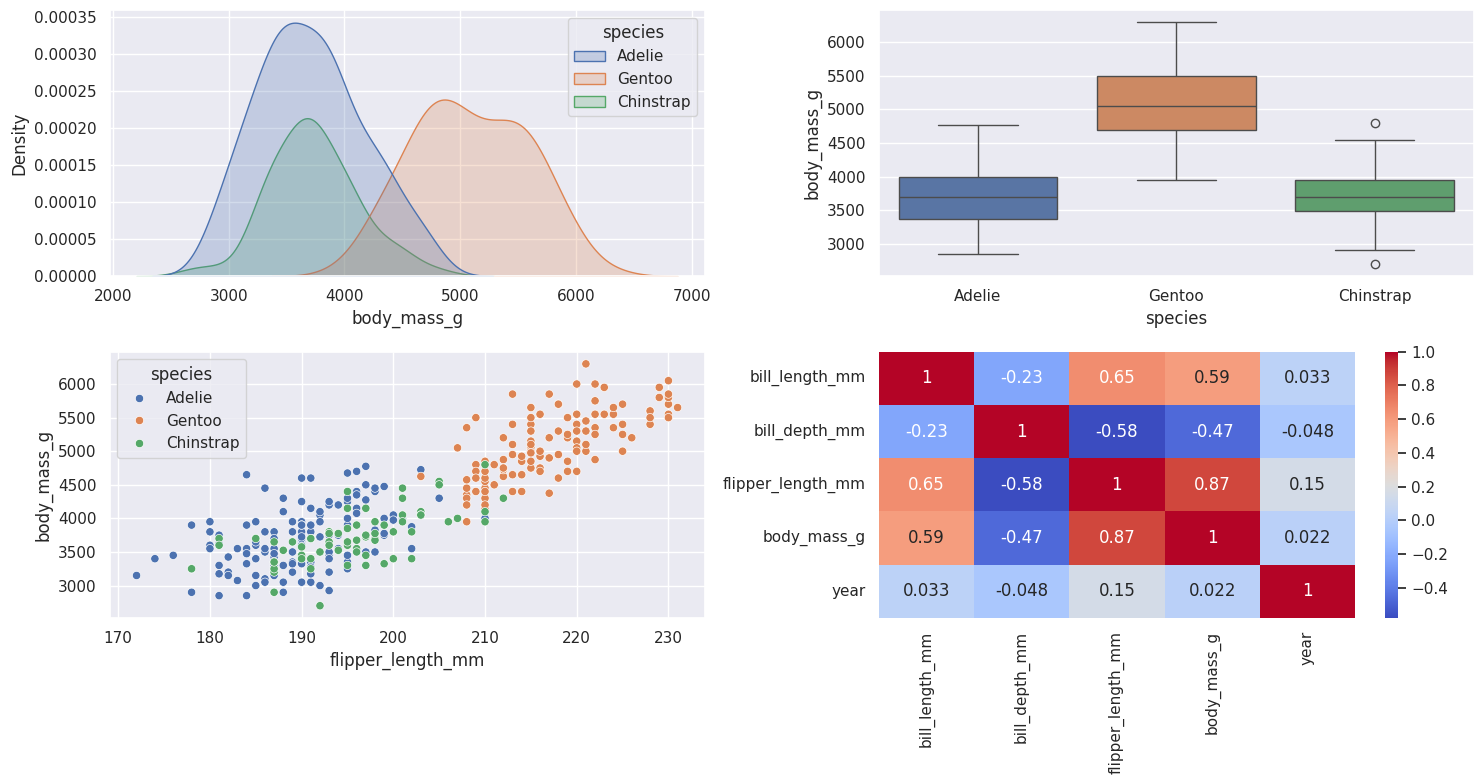

In [115]:
_, axes = plt.subplots(2, 2, figsize=(15,8))

sns.kdeplot(data=df, x="body_mass_g", hue="species", fill=True, ax=axes[0][0])

sns.boxplot(data=df, x="species", y="body_mass_g", hue="species", ax=axes[0][1])

sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g", hue="species", ax=axes[1][0])

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=axes[1][1])

plt.tight_layout()
plt.show()

Criar figura 2x2 com:
- Histograma massa
- Boxplot espécie
- Scatter flipper vs massa
- Heatmap correlação